In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class Graph:
    def __init__(self, num_nodes):
        self.num_nodes = num_nodes
        self.adjacency = {i: [] for i in range(num_nodes)}

    def add_edge(self, i, j, weight):
        if not any(neigh == j for neigh, _ in self.adjacency[i]):
            self.adjacency[i].append((j, weight))
            self.adjacency[j].append((i, weight))

    def neighbors(self, i):
        return self.adjacency[i]

    def edges(self):
        edge_list = []
        for i in range(self.num_nodes):
            for j, w in self.adjacency[i]:
                if i < j:
                    edge_list.append((i, j, w))
        return edge_list

In [17]:
class Map:
    def __init__(self, num_cities, seed=None):
        self.num_cities = num_cities
        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)

        self.cities = np.random.rand(num_cities, 2)

        self.graph = Graph(num_cities)
        self._generate_roads()

    def _generate_roads(self):
        for i in range(self.num_cities):
            distances = np.linalg.norm(self.cities - self.cities[i], axis=1)
            nearest_indices = np.argsort(distances)[1:]  # exclut self
            k = random.randint(1, 4)
            added = 0
            for j in nearest_indices:
                if all(neigh != j for neigh, _ in self.graph.neighbors(i)):
                    self.graph.add_edge(i, j, distances[j])
                    added += 1
                if added >= k:
                    break

    def plot(self, figsize=(6, 6), path=None):
        plt.figure(figsize=figsize)
        
        for i, j, _ in self.graph.edges():
            x = [self.cities[i][0], self.cities[j][0]]
            y = [self.cities[i][1], self.cities[j][1]]
            plt.plot(x, y, 'k-', alpha=0.5)

        plt.scatter(self.cities[:, 0], self.cities[:, 1], color='red')
        for idx, (x, y) in enumerate(self.cities):
            plt.text(x + 0.01, y + 0.01, str(idx), fontsize=8)

        if path:
            for i in range(len(path)-1):
                a, b = path[i], path[i+1]
                x = [self.cities[a][0], self.cities[b][0]]
                y = [self.cities[a][1], self.cities[b][1]]
                plt.plot(x, y, color='blue', linewidth=2)

        plt.title("Carte des villes et routes")
        plt.grid(True)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.show()

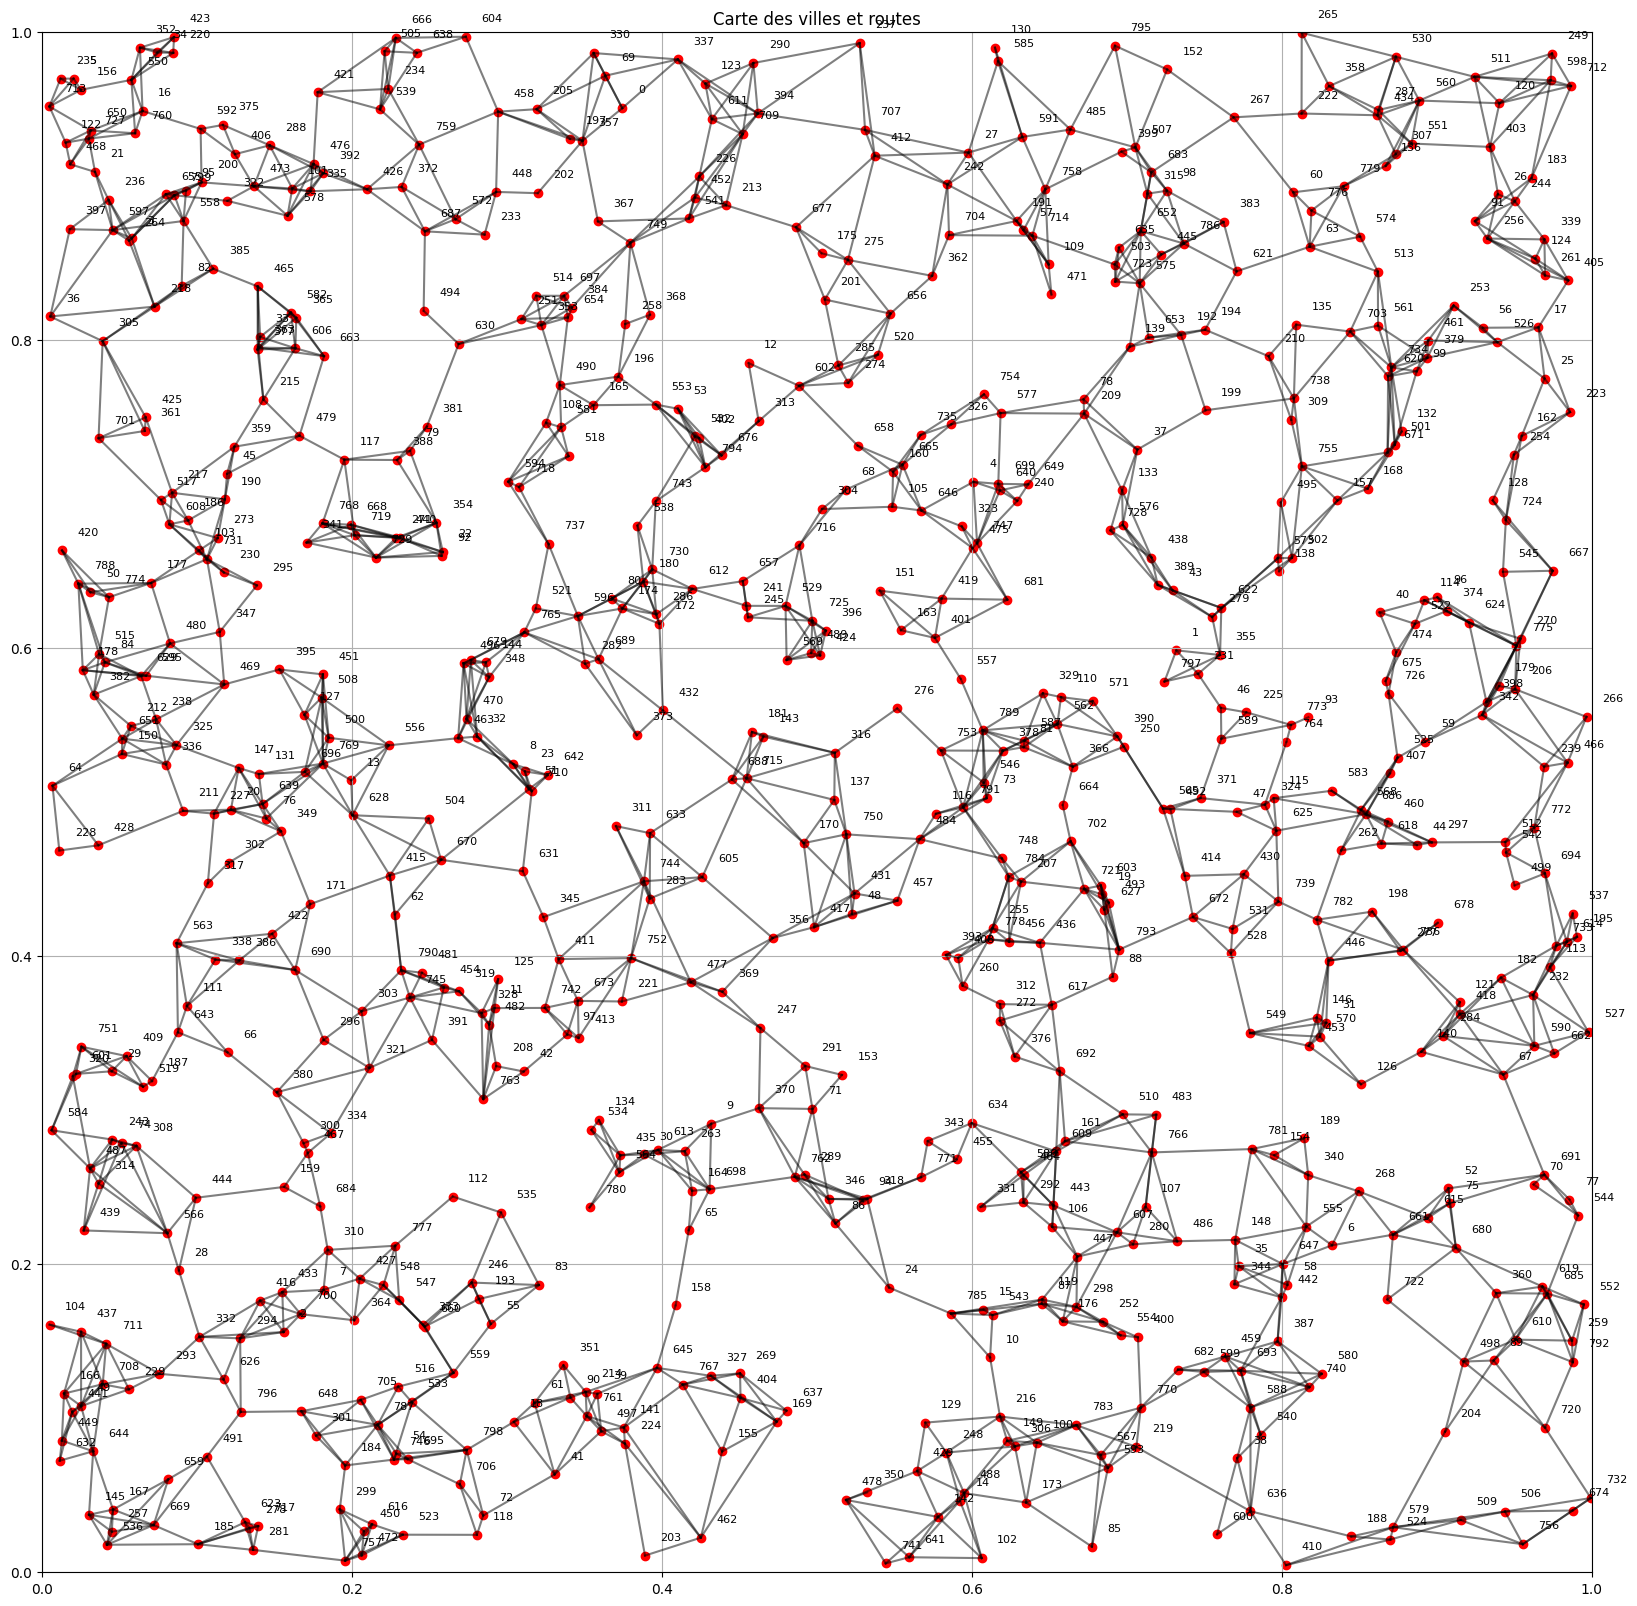

In [18]:
m = Map(num_cities=800, seed=42)
m.plot(figsize=(20, 20))

In [ ]:
def monte_carlo_path(graph, start, goal, num_trials=1000, max_steps=100):
    best_path = None
    best_distance = float('inf')

    for _ in range(num_trials):
        current = start
        visited = set([current])
        path = [current]
        total_dist = 0

        for _ in range(max_steps):
            neighbors = [v for v, _ in graph.neighbors(current) if v not in visited]
            if not neighbors:
                break

            next_city = random.choice(neighbors)
            dist = next(w for v, w in graph.neighbors(current) if v == next_city)

            path.append(next_city)
            total_dist += dist
            visited.add(next_city)
            current = next_city

            if current == goal:
                if total_dist < best_distance:
                    best_distance = total_dist
                    best_path = list(path)
                break

    return best_path, best_distance

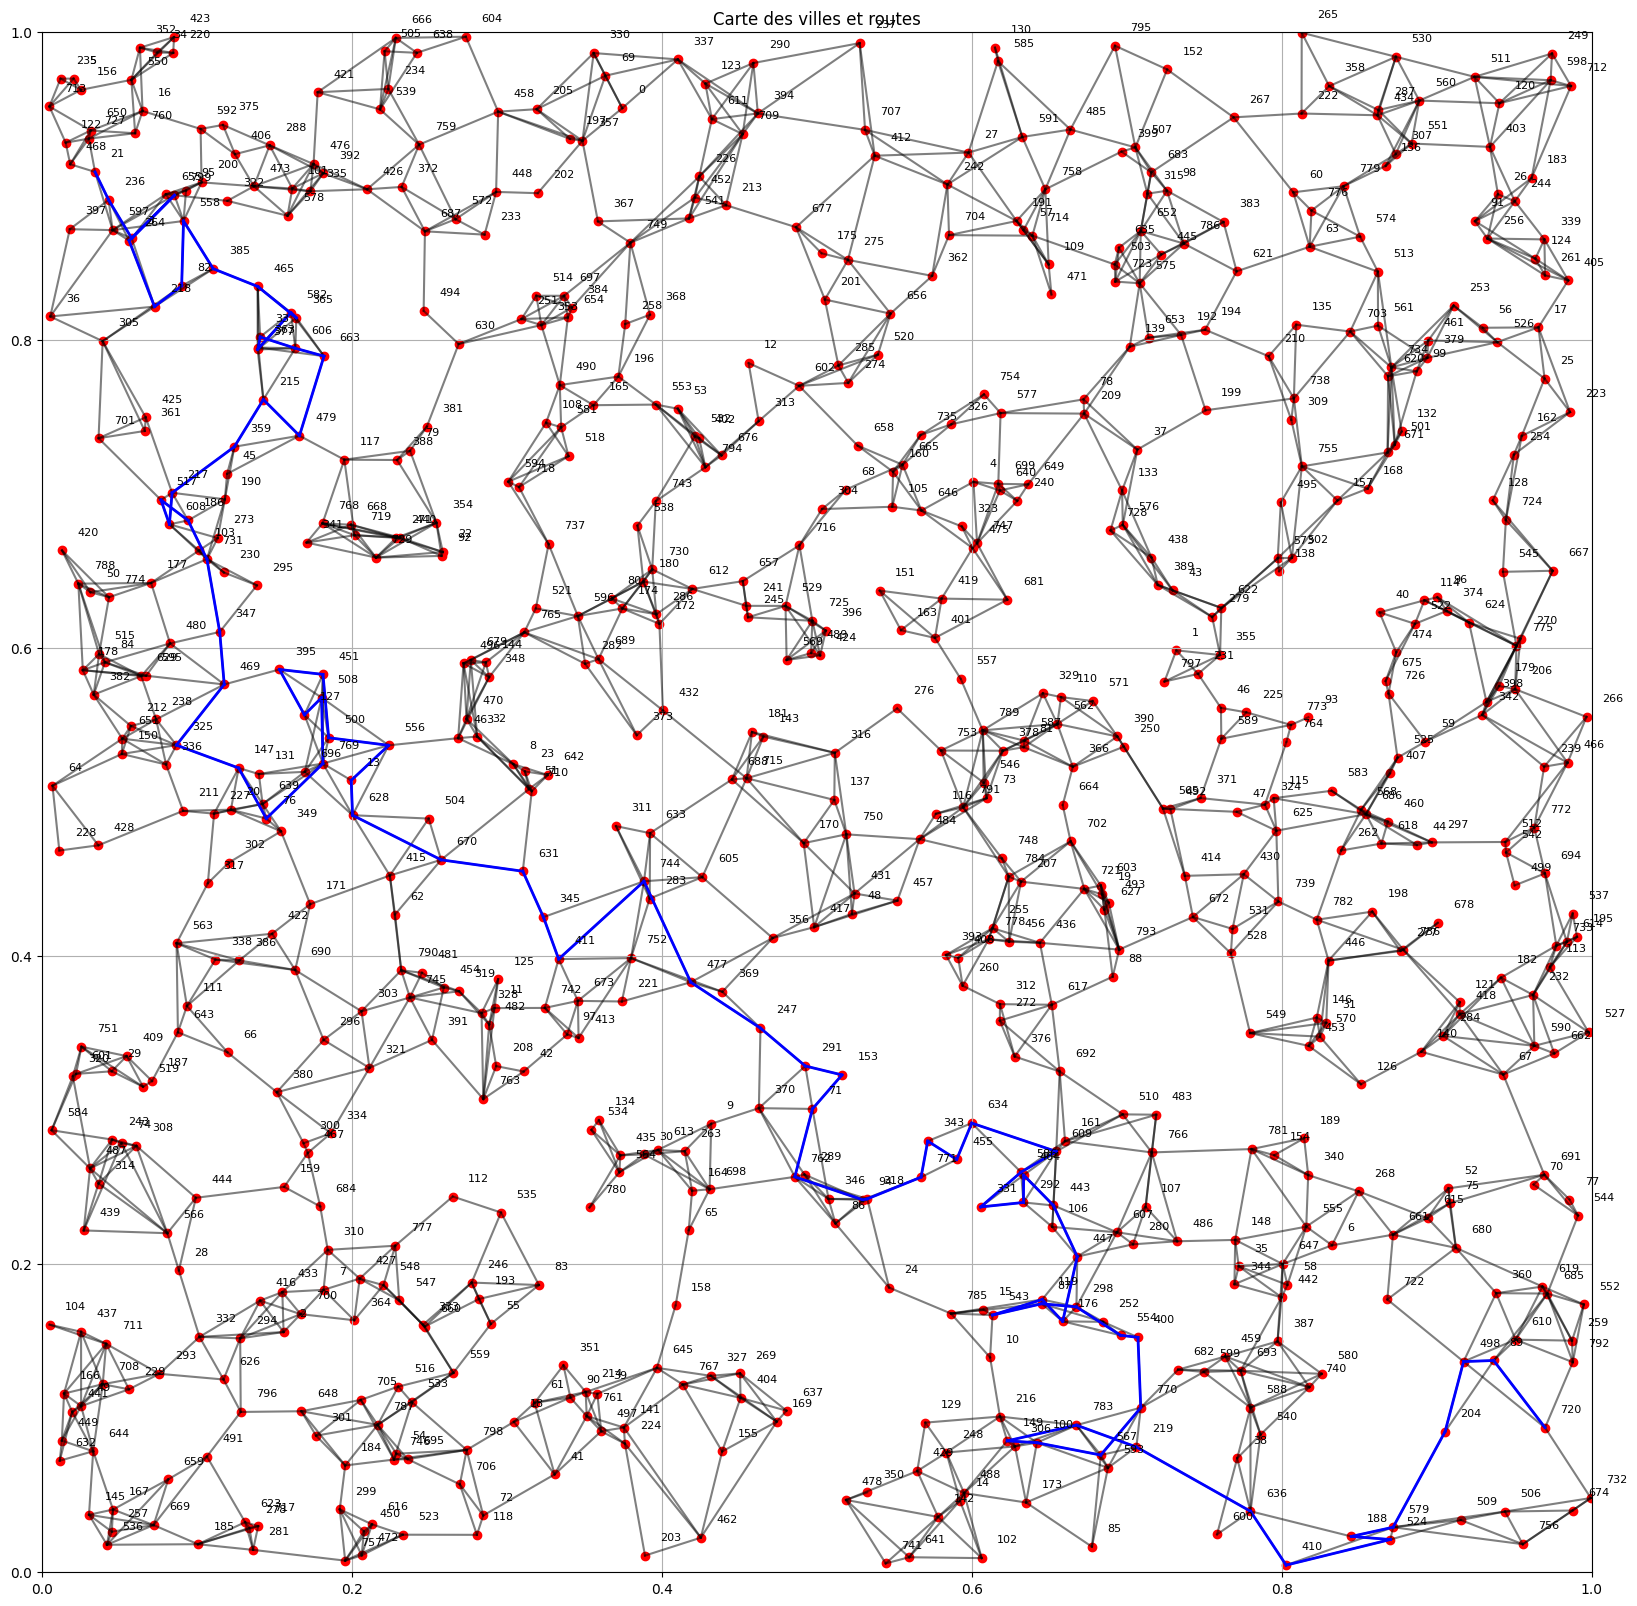

In [23]:
best_path, best_distance = monte_carlo_path(graph=m.graph, start=21, goal=720, num_trials=100_000, max_steps=10_000)
m.plot(figsize=(20, 20), path=best_path)